In [5]:
import pandas as pd

In [6]:
df = pd.read_csv('./data/titanic.csv')
df.sample(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
823,824,1,3,"Moor, Mrs. (Beila)",female,27.0,0,1,392096,12.475,E121,S
443,444,1,2,"Reynaldo, Ms. Encarnacion",female,28.0,0,0,230434,13.000,NaN,S


In [7]:
print(f"El shape del conjunto de entrenamiento es {df.shape}. {df.shape[0]} filas y {df.shape[1]} columnas.") 

El shape del conjunto de entrenamiento es (891, 12). 891 filas y 12 columnas.


In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


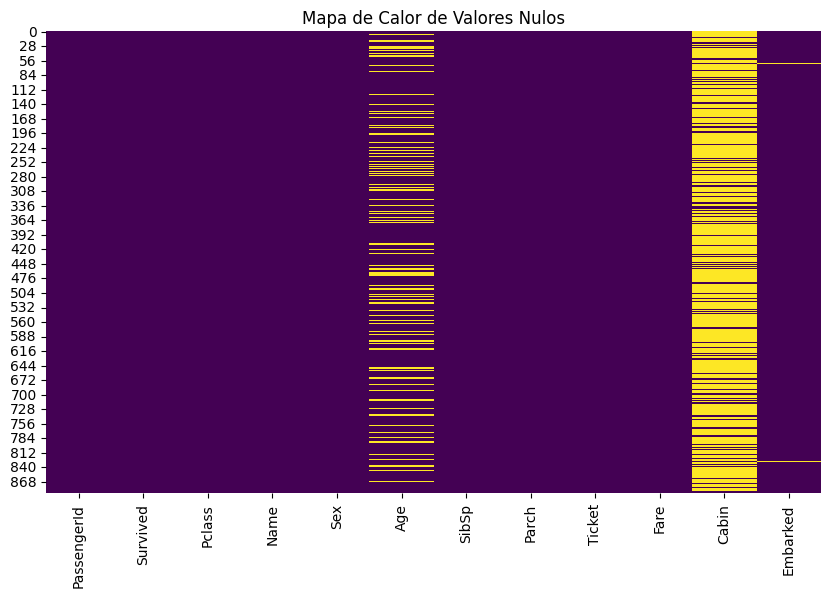

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Suponiendo que tu dataframe se llama 'df'
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Mapa de Calor de Valores Nulos')

# Guardar el gráfico como un archivo PNG
plt.savefig('output.png', format='png')

# Mostrar el gráfico
plt.show()

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
missing_values_percentage = df.isnull().mean() * 100
missing_values_percentage = missing_values_percentage.round(2).sort_values(ascending=False)
print(missing_values_percentage)

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64


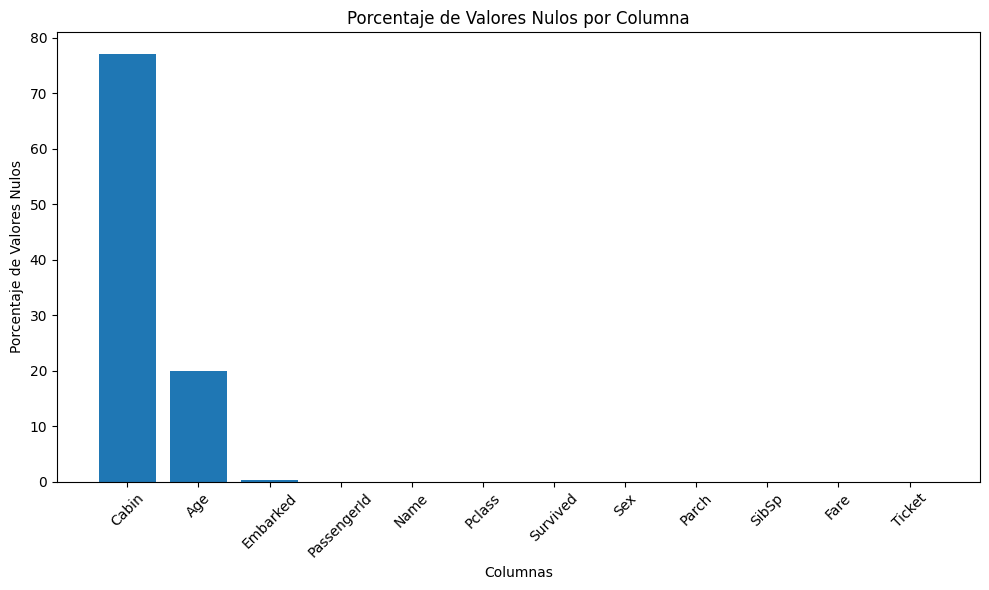

In [12]:
plt.figure(figsize=(10, 6))
plt.bar(missing_values_percentage.index, missing_values_percentage.values)
plt.xlabel('Columnas')
plt.ylabel('Porcentaje de Valores Nulos')
plt.title('Porcentaje de Valores Nulos por Columna')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
type(missing_values_percentage)

pandas.Series

In [14]:
missing_values_percentage.index

Index(['Cabin', 'Age', 'Embarked', 'PassengerId', 'Name', 'Pclass', 'Survived',
       'Sex', 'Parch', 'SibSp', 'Fare', 'Ticket'],
      dtype='str')

---
# ¿Que haremos con los valores faltantes?

In [15]:
df.columns

df.drop(columns=['Cabin'], inplace=True)

In [16]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


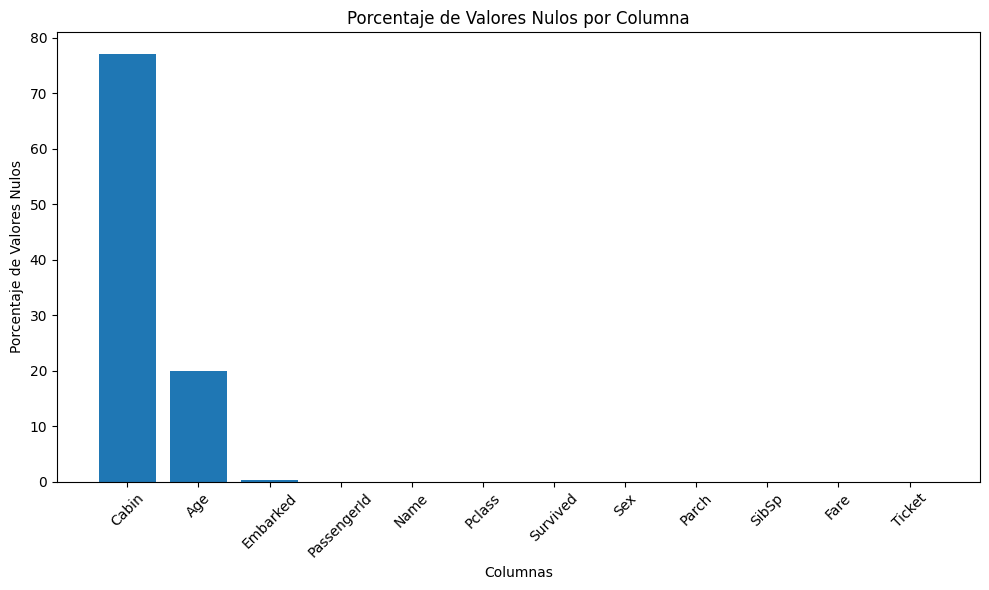

In [17]:
plt.figure(figsize=(10, 6))
plt.bar(missing_values_percentage.index, missing_values_percentage.values)
plt.xlabel('Columnas')
plt.ylabel('Porcentaje de Valores Nulos')
plt.title('Porcentaje de Valores Nulos por Columna')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

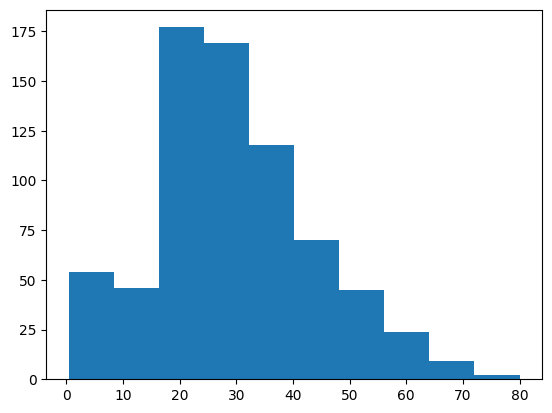

In [18]:
plt.hist(df['Age'])

In [19]:
#calcular la mediana de la columna Age
median_age = df['Age'].median()

#imputar los valores nulos con la mediana
df.Age = df['Age'].fillna(median_age)

In [20]:
df.Age.isnull().sum()

np.int64(0)

In [21]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [22]:
round(df.isnull().sum().sort_values(ascending=False) / len(df) * 100, 2)


PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.drop('Name', axis=1, inplace=True)
df.drop('Ticket', axis=1, inplace=True)
df.drop('PassengerId', axis=1, inplace=True)

In [25]:
print(f"El shape del conjunto de entrenamiento es {df.shape}. {df.shape[0]} filas y {df.shape[1]} columnas.")

El shape del conjunto de entrenamiento es (891, 8). 891 filas y 8 columnas.


In [26]:
df.to_csv('./data/titanic_clean.csv', index=False)  